In [1]:
import ipaddress
import pandas as pd
import matplotlib.pyplot as plt

# Keep consistent with other analysis notebooks
TIME_OFFSET = 10800

In [3]:
def plot_sum_is_stacked_per_src_ip(
    input_csv,
    src_ip,
    center_timestamp,
    interval_seconds,
    tcp_len_col="tcp.len",
    mbtcp_len_col="mbtcp.len",
    time_offset_seconds=TIME_OFFSET,
):
    """
    1) Plot sum(is_stacked) per src IP in 1-second bins, where:
       is_stacked = tcp.len > (mbtcp.len + 6)
    """
    ipaddress.ip_address(src_ip)
    df = pd.read_csv(input_csv)

    required_cols = {"ip.src", "frame.time_epoch", tcp_len_col, mbtcp_len_col}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required column(s): {sorted(missing)}")

    epoch = pd.to_numeric(df["frame.time_epoch"], errors="coerce")
    df = df.loc[epoch.notna()].copy()
    df["aligned_ts"] = pd.to_datetime(
        epoch[epoch.notna()] + float(time_offset_seconds),
        unit="s",
        errors="coerce",
    )

    tcp_len = pd.to_numeric(df[tcp_len_col], errors="coerce")
    mbtcp_len = pd.to_numeric(df[mbtcp_len_col], errors="coerce")
    df["is_stacked"] = (tcp_len > (mbtcp_len + 6)).fillna(False).astype(int)

    center_ts = pd.to_datetime(center_timestamp, errors="raise")
    start_ts = center_ts - pd.Timedelta(seconds=int(interval_seconds))
    end_ts = center_ts + pd.Timedelta(seconds=int(interval_seconds))

    src_df = df[df["ip.src"].astype(str) == src_ip].copy()
    window_df = src_df[(src_df["aligned_ts"] >= start_ts) & (src_df["aligned_ts"] <= end_ts)].copy()
    window_df["second_bin"] = window_df["aligned_ts"].dt.floor("s")

    center_second = center_ts.floor("s")
    bins = pd.date_range(
        start=center_second - pd.Timedelta(seconds=int(interval_seconds)),
        end=center_second + pd.Timedelta(seconds=int(interval_seconds)),
        freq="s",
    )
    rel_x = (bins - center_second).total_seconds().astype(int)

    series = window_df.groupby("second_bin")["is_stacked"].sum().reindex(bins, fill_value=0)

    plt.figure(figsize=(11, 4))
    plt.plot(rel_x, series.values, marker="o")
    plt.axvline(0, color="black", linestyle="--", linewidth=1, label="Target timestamp")
    plt.xlabel("Seconds offset from target timestamp")
    plt.ylabel("sum(is_stacked)")
    plt.title(f"Stacked-frame count for src={src_ip} around {center_ts} (+/-{interval_seconds}s)")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return series


def plot_mean_tcp_minus_mbtcp_len_per_src_ip(
    input_csv,
    src_ip,
    center_timestamp,
    interval_seconds,
    tcp_len_col="tcp.len",
    mbtcp_len_col="mbtcp.len",
    time_offset_seconds=TIME_OFFSET,
):
    """
    2) Plot mean(tcp.len - mbtcp.len) per src IP in 1-second bins.
    """
    ipaddress.ip_address(src_ip)
    df = pd.read_csv(input_csv)

    required_cols = {"ip.src", "frame.time_epoch", tcp_len_col, mbtcp_len_col}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required column(s): {sorted(missing)}")

    epoch = pd.to_numeric(df["frame.time_epoch"], errors="coerce")
    df = df.loc[epoch.notna()].copy()
    df["aligned_ts"] = pd.to_datetime(
        epoch[epoch.notna()] + float(time_offset_seconds),
        unit="s",
        errors="coerce",
    )

    tcp_len = pd.to_numeric(df[tcp_len_col], errors="coerce")
    mbtcp_len = pd.to_numeric(df[mbtcp_len_col], errors="coerce")
    df["tcp_minus_mbtcp_len"] = tcp_len - mbtcp_len

    center_ts = pd.to_datetime(center_timestamp, errors="raise")
    start_ts = center_ts - pd.Timedelta(seconds=int(interval_seconds))
    end_ts = center_ts + pd.Timedelta(seconds=int(interval_seconds))

    src_df = df[df["ip.src"].astype(str) == src_ip].copy()
    window_df = src_df[(src_df["aligned_ts"] >= start_ts) & (src_df["aligned_ts"] <= end_ts)].copy()
    window_df["second_bin"] = window_df["aligned_ts"].dt.floor("s")

    center_second = center_ts.floor("s")
    bins = pd.date_range(
        start=center_second - pd.Timedelta(seconds=int(interval_seconds)),
        end=center_second + pd.Timedelta(seconds=int(interval_seconds)),
        freq="s",
    )
    rel_x = (bins - center_second).total_seconds().astype(int)

    series = window_df.groupby("second_bin")["tcp_minus_mbtcp_len"].mean().reindex(bins)

    plt.figure(figsize=(11, 4))
    plt.plot(rel_x, series.values, marker="o")
    plt.axvline(0, color="black", linestyle="--", linewidth=1, label="Target timestamp")
    plt.xlabel("Seconds offset from target timestamp")
    plt.ylabel("mean(tcp.len - mbtcp.len)")
    plt.title(f"Mean (tcp.len - mbtcp.len) for src={src_ip} around {center_ts} (+/-{interval_seconds}s)")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return series


def plot_packet_count_vs_nunique_trans_id_per_src_ip(
    input_csv,
    src_ip,
    center_timestamp,
    interval_seconds,
    trans_id_col="mbtcp.trans_id",
    time_offset_seconds=TIME_OFFSET,
):
    """
    3) Plot packet_count vs nunique(mbtcp.trans_id) per src IP in 1-second bins.
    """
    ipaddress.ip_address(src_ip)
    df = pd.read_csv(input_csv)

    required_cols = {"ip.src", "frame.time_epoch", trans_id_col}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required column(s): {sorted(missing)}")

    epoch = pd.to_numeric(df["frame.time_epoch"], errors="coerce")
    df = df.loc[epoch.notna()].copy()
    df["aligned_ts"] = pd.to_datetime(
        epoch[epoch.notna()] + float(time_offset_seconds),
        unit="s",
        errors="coerce",
    )

    center_ts = pd.to_datetime(center_timestamp, errors="raise")
    start_ts = center_ts - pd.Timedelta(seconds=int(interval_seconds))
    end_ts = center_ts + pd.Timedelta(seconds=int(interval_seconds))

    src_df = df[df["ip.src"].astype(str) == src_ip].copy()
    window_df = src_df[(src_df["aligned_ts"] >= start_ts) & (src_df["aligned_ts"] <= end_ts)].copy()
    window_df["second_bin"] = window_df["aligned_ts"].dt.floor("s")

    center_second = center_ts.floor("s")
    bins = pd.date_range(
        start=center_second - pd.Timedelta(seconds=int(interval_seconds)),
        end=center_second + pd.Timedelta(seconds=int(interval_seconds)),
        freq="s",
    )
    rel_x = (bins - center_second).total_seconds().astype(int)

    packet_count = window_df.groupby("second_bin").size().reindex(bins, fill_value=0)
    nunique_trans_id = window_df.groupby("second_bin")[trans_id_col].nunique().reindex(bins, fill_value=0)

    plt.figure(figsize=(11, 4))
    plt.plot(rel_x, packet_count.values, marker="o", label="packet_count")
    plt.plot(rel_x, nunique_trans_id.values, marker="o", label=f"nunique({trans_id_col})")
    plt.axvline(0, color="black", linestyle="--", linewidth=1, label="Target timestamp")
    plt.xlabel("Seconds offset from target timestamp")
    plt.ylabel("count")
    plt.title(f"packet_count vs nunique(trans_id) for src={src_ip} around {center_ts} (+/-{interval_seconds}s)")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return packet_count, nunique_trans_id


# Example usage:
# input_csv = "../train/cscada_attack_ssw.csv"
# src_ip = "185.175.0.5"
# center_timestamp = "2023-03-19 03:01:57.813"
# x = 20
#
# plot_sum_is_stacked_per_src_ip(input_csv, src_ip, center_timestamp, x)
# plot_mean_tcp_minus_mbtcp_len_per_src_ip(input_csv, src_ip, center_timestamp, x)
# plot_packet_count_vs_nunique_trans_id_per_src_ip(input_csv, src_ip, center_timestamp, x)

/tmp/ipykernel_459654/1161195147.py:15: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16, 11: modbus.data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


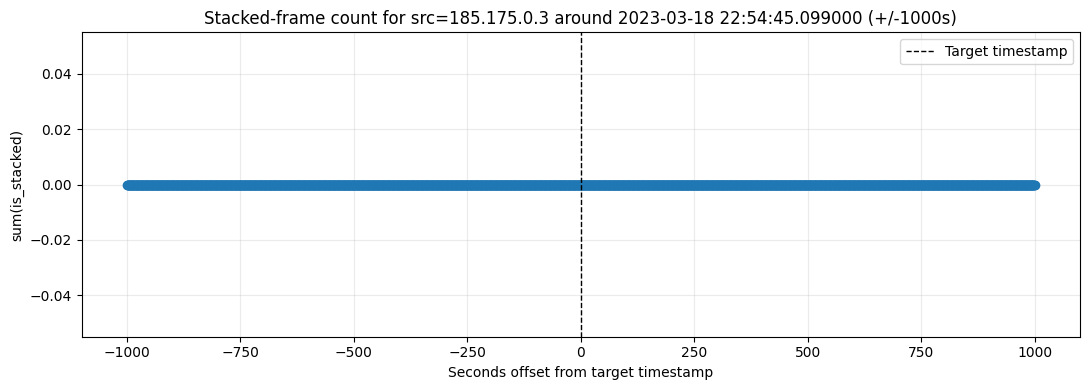

/tmp/ipykernel_459654/1161195147.py:15: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16, 11: modbus.data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


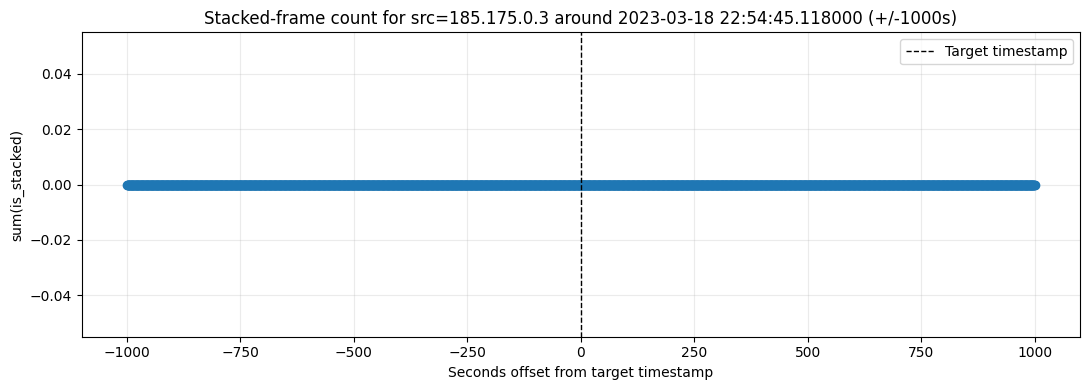

2023-03-18 22:38:05    0
2023-03-18 22:38:06    0
2023-03-18 22:38:07    0
2023-03-18 22:38:08    0
2023-03-18 22:38:09    0
                      ..
2023-03-18 23:11:21    0
2023-03-18 23:11:22    0
2023-03-18 23:11:23    0
2023-03-18 23:11:24    0
2023-03-18 23:11:25    0
Freq: s, Name: is_stacked, Length: 2001, dtype: int64

In [7]:
plot_sum_is_stacked_per_src_ip("../train/cscada_attack_ssw_analysis.csv", "185.175.0.3", "2023-03-18 22:54:45.099", 1000)
plot_sum_is_stacked_per_src_ip("../train/cscada_attack_ssw_analysis.csv", "185.175.0.3", "2023-03-18 22:54:45.118", 1000)


/tmp/ipykernel_459654/1161195147.py:79: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16, 11: modbus.data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


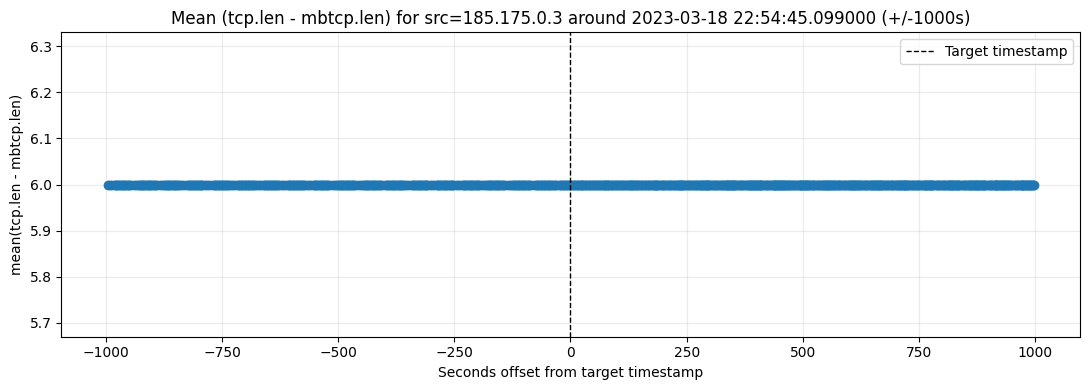

/tmp/ipykernel_459654/1161195147.py:79: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16, 11: modbus.data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


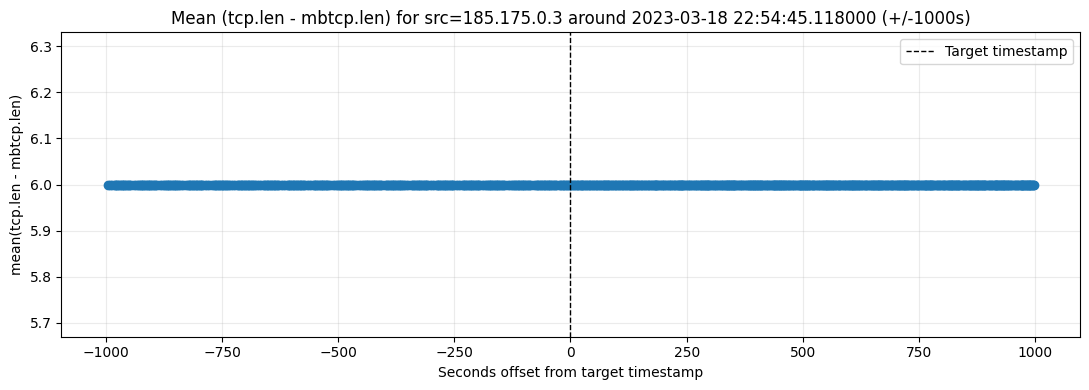

/tmp/ipykernel_459654/1161195147.py:79: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16, 11: modbus.data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


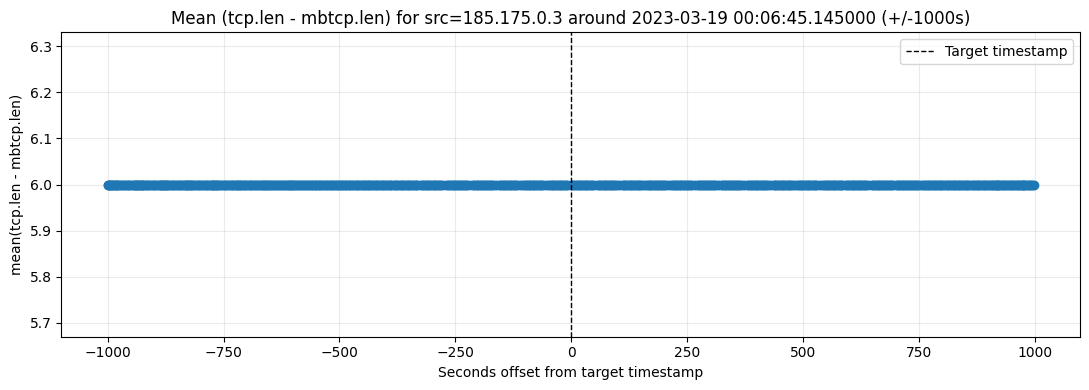

2023-03-18 23:50:05    6.0
2023-03-18 23:50:06    6.0
2023-03-18 23:50:07    6.0
2023-03-18 23:50:08    NaN
2023-03-18 23:50:09    NaN
                      ... 
2023-03-19 00:23:21    NaN
2023-03-19 00:23:22    6.0
2023-03-19 00:23:23    6.0
2023-03-19 00:23:24    NaN
2023-03-19 00:23:25    NaN
Freq: s, Name: tcp_minus_mbtcp_len, Length: 2001, dtype: float64

In [9]:
plot_mean_tcp_minus_mbtcp_len_per_src_ip("../train/cscada_attack_ssw_analysis.csv", "185.175.0.3", "2023-03-18 22:54:45.099", 1000)
plot_mean_tcp_minus_mbtcp_len_per_src_ip("../train/cscada_attack_ssw_analysis.csv", "185.175.0.3", "2023-03-18 22:54:45.118", 1000)
plot_mean_tcp_minus_mbtcp_len_per_src_ip("../train/cscada_attack_ssw_analysis.csv", "185.175.0.3", "2023-03-19 00:06:45.145", 1000)


/tmp/ipykernel_459654/1161195147.py:142: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16, 11: modbus.data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


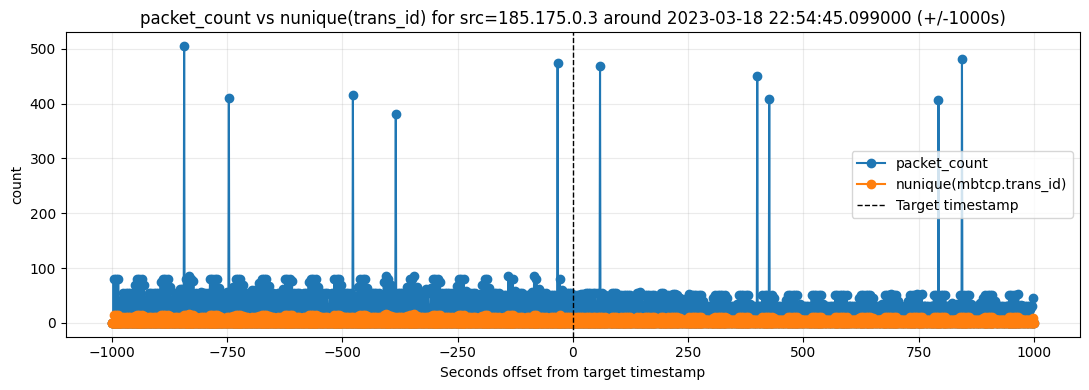

/tmp/ipykernel_459654/1161195147.py:142: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16, 11: modbus.data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


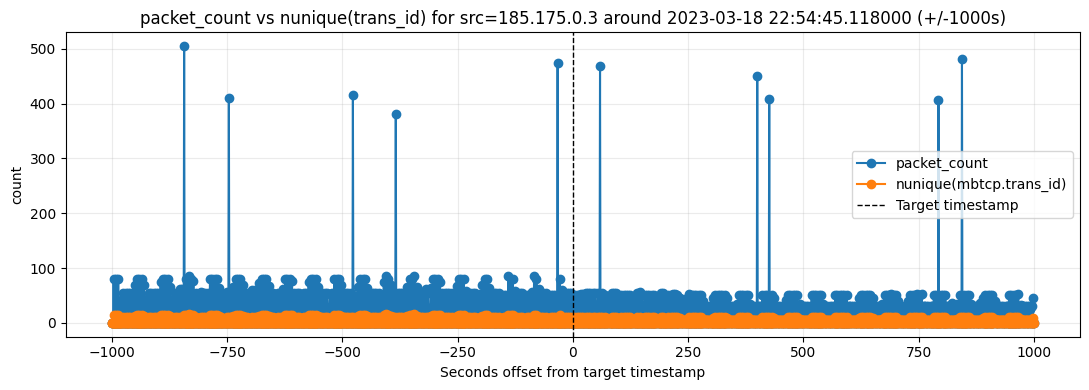

/tmp/ipykernel_459654/1161195147.py:142: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16, 11: modbus.data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


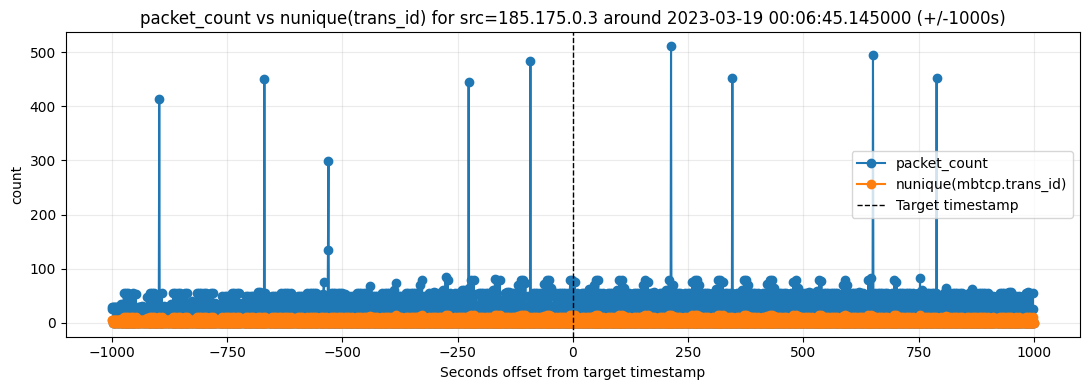

(2023-03-18 23:50:05    30
 2023-03-18 23:50:06    25
 2023-03-18 23:50:07    30
 2023-03-18 23:50:08     0
 2023-03-18 23:50:09     0
                        ..
 2023-03-19 00:23:21     0
 2023-03-19 00:23:22    55
 2023-03-19 00:23:23    25
 2023-03-19 00:23:24     0
 2023-03-19 00:23:25     0
 Freq: s, Length: 2001, dtype: int64,
 2023-03-18 23:50:05     6
 2023-03-18 23:50:06     5
 2023-03-18 23:50:07     5
 2023-03-18 23:50:08     0
 2023-03-18 23:50:09     0
                        ..
 2023-03-19 00:23:21     0
 2023-03-19 00:23:22    10
 2023-03-19 00:23:23     5
 2023-03-19 00:23:24     0
 2023-03-19 00:23:25     0
 Freq: s, Name: mbtcp.trans_id, Length: 2001, dtype: int64)

In [10]:
plot_packet_count_vs_nunique_trans_id_per_src_ip("../train/cscada_attack_ssw_analysis.csv", "185.175.0.3", "2023-03-18 22:54:45.099", 1000)
plot_packet_count_vs_nunique_trans_id_per_src_ip("../train/cscada_attack_ssw_analysis.csv", "185.175.0.3", "2023-03-18 22:54:45.118", 1000)
plot_packet_count_vs_nunique_trans_id_per_src_ip("../train/cscada_attack_ssw_analysis.csv", "185.175.0.3", "2023-03-19 00:06:45.145", 1000)